# Natural Language Processing

Natural Language Processing (NLP) is the overall discipline of getting computers to process, analyze, and manipulate human language. It involves both the input (reading/hearing) and the output (writing/speaking).

NLP handles the structural and technical heavy lifting, such as:

Tokenization: Breaking sentences into individual words or "tokens."

Stemming and Lemmatization: Reducing words to their root form (e.g., "running" becomes "run").

Part-of-Speech Tagging: Identifying nouns, verbs, and adjectives.

Named Entity Recognition (NER): Identifying names, dates, and locations.

NLU is a subset of NLP. While NLP focuses on processing the data, NLU focuses on intent and meaning. It is the hardest part of AI because human language is messy, filled with sarcasm, metaphors, and cultural context.

NLU's primary goals are:

Intent Recognition: What does the user actually want? (e.g., "It's cold in here" might mean "Turn up the heat").

Entity Extraction: Pulling the specific "values" from a request (e.g., in "Book a flight to Mumbai," the entity is the destination).

Disambiguation: Determining which meaning of a word is being used (e.g., "bank" as a financial institution vs. "bank" of a river).

### Bag of Words

In [1]:
import pandas as pd
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

Load the dataset

In [3]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

Preprocessing function

In [4]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()  # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    return text

In [5]:
# Apply cleaning to the text column (ignoring location as requested)
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

Create the Corpus and Bag of Words (BoW)

In [6]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)

Fit on train data, then transform both train and test

In [8]:
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

In [9]:
# Target variable from train.csv
y_train = train_df['target']

Classify using Naive Bayes

In [10]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

In [11]:
test_predictions = clf.predict(X_test)

Evaluate training accuracy

In [14]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [15]:
train_preds = clf.predict(X_train)
accuracy = accuracy_score(y_train, train_preds)
report = classification_report(y_train, train_preds, target_names=['Non-Disaster (0)', 'Disaster (1)'])

print(f"Overall Accuracy: {accuracy:.4%}")
print("\nClassification Report:\n", report)

Overall Accuracy: 86.0370%

Classification Report:
                   precision    recall  f1-score   support

Non-Disaster (0)       0.85      0.92      0.88      4342
    Disaster (1)       0.88      0.78      0.83      3271

        accuracy                           0.86      7613
       macro avg       0.86      0.85      0.86      7613
    weighted avg       0.86      0.86      0.86      7613



Confusion Matrix

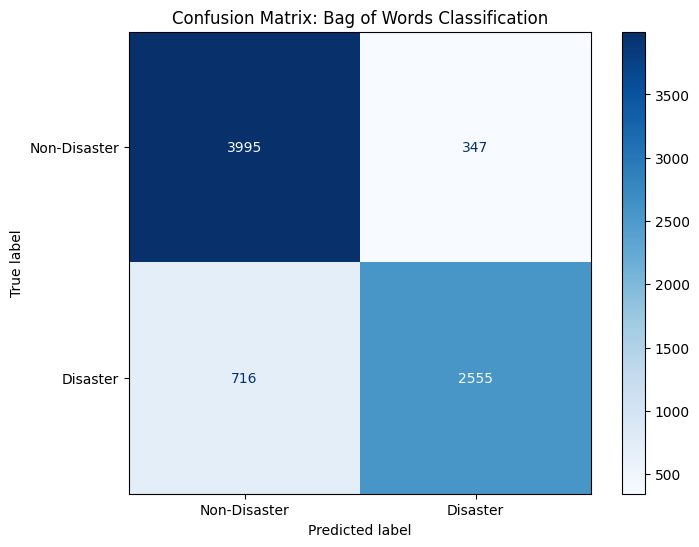

In [16]:
cm = confusion_matrix(y_train, train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Bag of Words Classification")
plt.savefig('accuracy_metrics.png')
plt.show()

Classify using Logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
train_preds = lr_clf.predict(X_train)
accuracy = accuracy_score(y_train, train_preds)
report = classification_report(y_train, train_preds, target_names=['Non-Disaster (0)', 'Disaster (1)'])

print(f"Logistic Regression Accuracy: {accuracy:.4%}")
print("\nClassification Report:\n", report)

Logistic Regression Accuracy: 91.3043%

Classification Report:
                   precision    recall  f1-score   support

Non-Disaster (0)       0.89      0.96      0.93      4342
    Disaster (1)       0.95      0.85      0.89      3271

        accuracy                           0.91      7613
       macro avg       0.92      0.90      0.91      7613
    weighted avg       0.92      0.91      0.91      7613



In [20]:
test_df['target_prediction'] = lr_clf.predict(X_test)
print("\nSample Predictions on test.csv:")
print(test_df[['text', 'target_prediction']].head())


Sample Predictions on test.csv:
                                                text  target_prediction
0                 Just happened a terrible car crash                  1
1  Heard about #earthquake is different cities, s...                  1
2  there is a forest fire at spot pond, geese are...                  1
3           Apocalypse lighting. #Spokane #wildfires                  1
4      Typhoon Soudelor kills 28 in China and Taiwan                  1


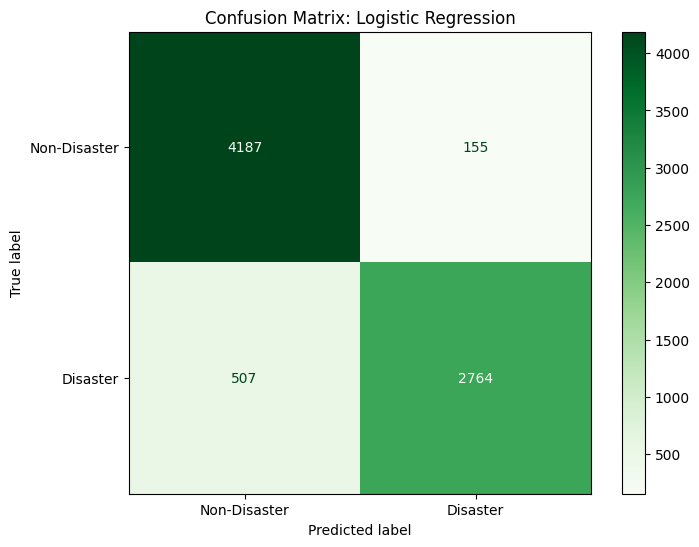

In [21]:
cm = confusion_matrix(y_train, train_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Disaster', 'Disaster'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Greens', ax=ax)
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

### TF-IDF

Create a TF-IDF Vectorizer

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

In [24]:
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_test_tfidf = tfidf.transform(test_df['clean_text'])
y_train = train_df['target']

In [25]:
lr_tfidf = LogisticRegression(max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [26]:
train_preds = lr_tfidf.predict(X_train_tfidf)
print(f"TF-IDF Accuracy: {accuracy_score(y_train, train_preds):.4%}")
print("\nClassification Report:\n", classification_report(y_train, train_preds))

TF-IDF Accuracy: 87.0879%

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4342
           1       0.92      0.76      0.84      3271

    accuracy                           0.87      7613
   macro avg       0.88      0.86      0.86      7613
weighted avg       0.88      0.87      0.87      7613



In [27]:
test_df['target_prediction'] = lr_tfidf.predict(X_test_tfidf)

### Using SpaCy

In [28]:
import spacy

Load SpaCy's English model

In [29]:
# 'disable' helps speed up the process by turning off unneeded components
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

SpaCy powered pre processing

In [30]:
def spacy_cleaner(text):
    if pd.isna(text):
        return ""

    # Remove URLs using regex
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Process text with SpaCy
    doc = nlp(text.lower())

    # Lemmatize and remove stop words + punctuation
    # .lemma_ gets the base form, .is_alpha ensures we only keep words
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]

    return " ".join(tokens)

In [31]:
print("Processing text with SpaCy...")
train_df['spacy_text'] = train_df['text'].apply(spacy_cleaner)
test_df['spacy_text'] = test_df['text'].apply(spacy_cleaner)

Processing text with SpaCy...


Vectorization with TF-IDF

In [32]:
tfidf = TfidfVectorizer(max_features=5000)
X_train = tfidf.fit_transform(train_df['spacy_text'])
X_test = tfidf.transform(test_df['spacy_text'])
y_train = train_df['target']

Logistic Regression

In [33]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Evaluation

In [34]:
train_preds = clf.predict(X_train)
print(f"SpaCy + Logistic Regression Accuracy: {accuracy_score(y_train, train_preds):.4%}")
print("\nClassification Report:\n", classification_report(y_train, train_preds))

SpaCy + Logistic Regression Accuracy: 86.8777%

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4342
           1       0.92      0.76      0.83      3271

    accuracy                           0.87      7613
   macro avg       0.88      0.86      0.86      7613
weighted avg       0.87      0.87      0.87      7613

